# covid19 charts
> making some charts

- toc: true
- badges: true
- comments: true
- author: Khalid Omar
- categories: [python]
- permalink: /covid19/
- hide: true

In [110]:
#hide

# utils
from datetime import datetime

# viz stuff
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import altair as alt
import plotly.express as px

# download
import requests
#from bs4 import BeautifulSoup

> Warning: This is just me trying to learn Altair + trying to answer my own questions.

# 1. Data

First up, loading datasets

## Pakistan Data

Code for Pakistan has made a [public app](https://github.com/codeforpakistan/covid19) and is updating data on a [google sheet](https://docs.google.com/spreadsheets/d/1ljt1URrDZRqTK0qke2yV3lD24CqrfnemhLKClMBYYrQ/edit#gid=357374787).

In [107]:
pk_url = "https://docs.google.com/spreadsheets/d/1ljt1URrDZRqTK0qke2yV3lD24CqrfnemhLKClMBYYrQ/export?format=csv&id=1ljt1URrDZRqTK0qke2yV3lD24CqrfnemhLKClMBYYrQ&gid=357374787"
dateparse = lambda x: datetime.strptime(x, "%d-%m-%y")
pk = pd.read_csv(pk_url, parse_dates=["Date"], date_parser=dateparse)
pk.head(2)

,Date,Province,Suspected_24,Suspected_Cum,Tested_24,Tested_Cum,Confirmed_24,Confirmed_Cum,Admitted_24,Admitted_Cum,Discharged_24,Discharged_Cum,Expired_24,Expired_Cum
0,2020-03-31,Islamabad,195.0,1395,159,1469,7,58,3,16,0,3,0,0
1,2020-03-31,Punjab,154.0,3770,-992,2500,59,652,50,303,0,5,3,9


In [113]:
pk.columns

Index(['Date', 'Province', 'Suspected_24', 'Suspected_Cum', 'Tested_24',
       'Tested_Cum', 'Confirmed_24', 'Confirmed_Cum', 'Admitted_24',
       'Admitted_Cum', 'Discharged_24', 'Discharged_Cum', 'Expired_24',
       'Expired_Cum'],
      dtype='object')

In [118]:
cases = alt.Chart(pk).mark_line(point=True).encode(
x="Date", y="Confirmed_Cum", color="Province")

tested = alt.Chart(pk).mark_line(point=True).encode(
x="Date", y="Tested_Cum", color="Province")

cases | tested

alt.HConcatChart(...)

## Global Data

Loading data from [the john hopkins data repo](https://github.com/CSSEGISandData/COVID-19), specifically the [time series data](https://github.com/CSSEGISandData/COVID-19/tree/master/csse_covid_19_data/csse_covid_19_time_series).

This has timeseries data for Deaths, Recovered and Confirmed cases.

In [149]:
#hide
def get_timeseries_data(verbose=False):
    """Downloads the three kinds of timeseries data
    and returns a dict with three dataframes"""

    data = []
    data_files = ["confirmed", "deaths", "recovered"]
    baseurl = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_19-covid"
    baseurl = baseurl= "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19"
    column_map = {'Province/State': 'state', 
                  'Country/Region': 'country',
                   'Lat': 'lat', 'Long': 'long'}
    
    for name in data_files:
        url = f"{baseurl}_{name}_global.csv"
        df = pd.read_csv(url)
        if verbose:
            print(f"Downloaded: {name} with shape {df.shape}")

        #df.rename(columns=column_map, inplace=True)
        df["type"] = name.lower() # type of case
        
        data.append(df)

    return data

def process_timeseries(df):
    """transforms dataframe to tidy format"""
    
    column_map = {'Province/State': 'state', 
                  'Country/Region': 'country',
                  'Lat': 'lat', 'Long': 'long'}
    
    df.rename(columns=column_map, inplace=True)
    
    name_cols = list(df.columns[:4]) + ["type"] 
    
    # make long form
    df = pd.melt(df, name_cols, var_name="Date", value_name="cases")
    
    df["date"] = pd.to_datetime(df.Date) # datetime format
    df.drop(columns="Date", inplace=True)
    
    df = df.groupby(["country", "date", "type"]).sum()
    df = df.reset_index()
    
    return df

df = pd.concat([process_timeseries(df) for df in get_timeseries_data()], 
               ignore_index=True)
df.head()

,country,date,type,lat,long,cases
0,Afghanistan,2020-01-22,confirmed,33.0,65.0,0
1,Afghanistan,2020-01-23,confirmed,33.0,65.0,0
2,Afghanistan,2020-01-24,confirmed,33.0,65.0,0
3,Afghanistan,2020-01-25,confirmed,33.0,65.0,0
4,Afghanistan,2020-01-26,confirmed,33.0,65.0,0


In [161]:
countries = ["Pakistan", "India", "Australia"]
d = df.query("country in @countries and type == 'deaths'")

alt.Chart(d).mark_line(point=True).encode(
    x="date", y="cases", color="country")

alt.Chart(...)

## Australia Data only

From [the Guardian](https://www.theguardian.com/news/datablog/ng-interactive/2020/mar/23/how-many-cases-of-coronavirus-are-there-in-australia-live-statistics), which is collecting the data from different sources and putting it all into a Google sheet.

In [164]:
#collapse
# google sheets and json
# https://www.theguardian.com/news/datablog/ng-interactive/2020/mar/23/how-many-cases-of-coronavirus-are-there-in-australia-live-statistics

aus_json_data = "https://interactive.guim.co.uk/docsdata/1q5gdePANXci8enuiS4oHUJxcxC13d6bjMRSicakychE.json"

r = requests.get(aus_json_data)
aus = r.json()
# now we have a dict object with one key, sheets
print(aus['sheets']['about'][0]['about'])
print(aus['sheets'].keys())

aus_totals = pd.DataFrame.from_records(aus['sheets']['latest totals'])
aus_updates = pd.DataFrame.from_records(aus['sheets']["updates"])
aus_totals

This data has been compiled by Guardian Australia from official state and territory media releases and websites. Some death dates and figures are from media reports. We assign cases to the date on which they were reported by the health department, and deaths are assigned to the date they occured. Extended data on testing and demographics varies between each state and territory so may not always be available. Please contact nick.evershed@theguardian.com if you spot an error in the data or to make a suggestion. This data is released under a Attribution 3.0 Australia (CC BY 3.0 AU) license, which means it is ok to re-use but please provide attribution and a link to Guardian Australia
dict_keys(['updates', 'latest totals', 'locations', 'age distribution', 'sources', 'about', 'data validation'])


,State or territory,Long name,Confirmed cases (cumulative),Deaths,Tests conducted,Tests per million,Percent positive,Last updated
0,NSW,New South Wales,2182,9,105543,13001,2.1,2020-03-31
1,VIC,Victoria,968,4,47000,7089,2.1,2020-04-01
2,QLD,Queensland,781,2,38860,7597,2.0,2020-04-01
3,SA,South Australia,337,,26000,14802,1.3,2020-03-31
4,ACT,Australian Capital Territory,84,1,4059,9481,2.1,2020-04-01
5,NT,Northern Territory,16,,,,,2020-03-31
6,TAS,Tasmania,69,2,1779,3322,3.9,2020-04-01
7,WA,Western Australia,392,2,14188,5393,2.8,2020-04-01
8,National,National,4829,20,237429,9324,2.0,2020-04-01


In [190]:
aus_updates.columns

Index(['State', 'Date', 'Time', 'Cumulative case count', 'Cumulative deaths',
       'Tests conducted (negative)', 'Tests conducted (total)',
       'Intensive care (count)', 'Hospitalisations (count)',
       'Recovered (cumulative)', 'Update Source', 'Under 60', 'Over 60',
       'Community', 'Community - no known source', 'Travel-related',
       'Under investigation', 'Notes'],
      dtype='object')

In [174]:
aus_updates.sort_values(by="Date", inplace=True)
aus_updates.head()

,State,Date,Time,Cumulative case count,Cumulative deaths,Tests conducted (negative),Tests conducted (total),Intensive care (count),Hospitalisations (count),Recovered (cumulative),Update Source,Under 60,Over 60,Community,Community - no known source,Travel-related,Under investigation,Notes
15,VIC,01/02/2020,,4,,,162,,,,Victoria DHHS,,,,,,,
14,NSW,01/02/2020,,4,,,100,,,,NSW Health,,,,,,,
13,SA,01/02/2020,,0,,,25,,,,SA Health website,,,,,,,
53,NSW,01/03/2020,,5,,,,,,,NSW Health media release,1,,,,1,,4 of 5 cases discharged
56,WA,01/03/2020,,,1,594,594,,,,WA Health,,,,,,,


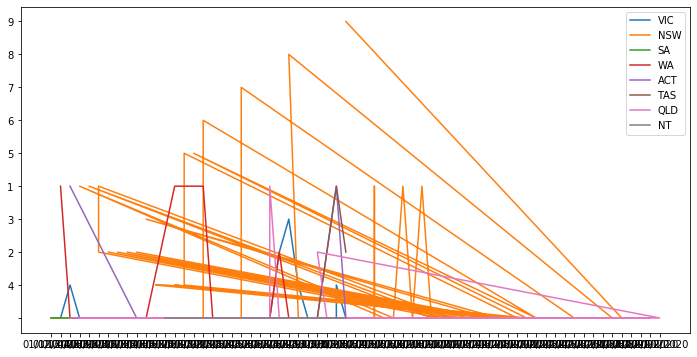

In [192]:
#hide
fig, ax = plt.subplots(figsize=(12,6))
for state in aus_updates.State.unique():
    ax.plot("Date", "Cumulative deaths", 
            data=aus_updates.query("State == @state"),
            label=state)
ax.legend()

In [167]:
#collapse
base = alt.Chart(aus_totals)

tests = base.mark_bar().encode(
    x="State or territory",
    y="Tests conducted:Q",
    color="State or territory"
).properties(
    title="Tests Conducted"
)

cases = base.mark_bar().encode(
    x="State or territory",
    y="Confirmed cases (cumulative):Q",
    color="State or territory"
).properties(
    title="Covid cases"
)

tests | cases

alt.HConcatChart(...)

# 2. SIR Model

In [193]:
pk

,Date,Province,Suspected_24,Suspected_Cum,Tested_24,Tested_Cum,Confirmed_24,Confirmed_Cum,Admitted_24,Admitted_Cum,Discharged_24,Discharged_Cum,Expired_24,Expired_Cum
0,2020-03-31,Islamabad,195.0,1395,159,1469,7,58,3,16,0,3,0,0
1,2020-03-31,Punjab,154.0,3770,-992,2500,59,652,50,303,0,5,3,9
2,2020-03-31,Sindh,383.0,6328,383,6328,119,627,9,315,26,42,2,7
3,2020-03-31,Khyber Pakhtunkhwa,312.0,1334,188,1512,26,221,10,70,0,2,1,6
4,2020-03-31,Balochistan,130.0,1825,82,1792,9,153,6,139,0,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,2020-03-10,Sindh,8.0,83,116,116,13,13,12,12,1,1,0,0
150,2020-03-10,Khyber Pakhtunkhwa,0.0,20,26,26,0,0,0,0,0,0,0,0
151,2020-03-10,Balochistan,0.0,15,14,14,0,0,0,0,0,0,0,0
152,2020-03-10,Azad Kashmir,0.0,3,4,4,0,0,0,0,0,0,0,0
